#· Diagnostic & Descriptive Models — Screening Peer-Lending Loans (Lending Club)

Data: `loans-kpi.csv` (9,578 three-year loans funded May 2007 – Feb 2010) with `LoansDataDescr.pdf`.



In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
warnings.filterwarnings("ignore")

DATA_PATH = "loans-kpi.csv"
SEED = 45952
FIG_DIR = "figs"; os.makedirs(FIG_DIR, exist_ok=True)

import seaborn as sns
sns.set_theme(style="whitegrid")
SEG_COLORS = {"Prime Borrowers": "tab:green", "Stretched Starters": "tab:blue", "Affluent but Leveraged": "tab:purple", "Credit Seekers": "tab:orange"}
os.makedirs("tables", exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

def save_fig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

def snap(frame, name):
    # show the table and keep an HTML copy so the exact output can be screenshotted for the slides
    display(frame)
    frame.to_html(f"tables/{name}.html")

## 1. Business understanding

**Situation.** Lending Club runs a peer-to-peer marketplace: investors fund three-year personal loans and borrowers repay monthly. The platform's reputation, and its cut of the interest, depends on featuring loans that get repaid.

**Decisions the ExCo is trying to make**
| Decision | Owner most exposed |
|---|---|
| **Which loan applications to feature to investors (screening)** | CEO: return on invested capital (ROIC) for platform users |
| How to price interest rates by risk tier | CFO: interest profit, of which Lending Club takes a cut |
| Which borrower segments to prioritize for growth | CMO: market share vs. Prosper and other competitors |

**Our focus:** the **screening decision**, i.e. flagging high-risk applications *before* they are shown to investors. We will check any screen against all three lenses: ROIC (CEO), net interest profit (CFO) and volume or approval rate (CMO). Pricing and growth come in as secondary insights.

**Source of value.** The historical record of funded loans and their outcomes tells us which application-time characteristics went with defaults and with profit. Update 1 describes those patterns. Update 2 turns them into a default-probability model. Update 3 picks the screening cutoff.

**KPIs (from the data description)**
- Paid loan: investor profit = `interest`. Defaulted loan: investor loss = `principal`.
- Net profit = Σ interest (paid loans) − Σ principal (defaulted loans)
- ROIC = net profit / Σ principal (over the 3-year term)
- Default rate, and share of loans kept (a proxy for market share)

**Hypotheses going in:** H1 lower FICO → more default · H2 more recent inquiries (credit-seeking) → more default · H3 higher rate → more default, but pricing may compensate · H4 small-business loans are riskier · H5 higher DTI or utilization → more default.

## 2. Data understanding
**Prompt:** *Load loans-kpi.csv, show its shape, column types and first rows.*

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.replace(".", "_") for c in df.columns]
print("Shape:", df.shape)
print(df.dtypes.to_string())
display(df.head())

Shape: (9578, 17)
credit_policy          int64
purpose                  str
int_rate             float64
installment          float64
log_annual_inc       float64
dti                  float64
fico                   int64
days_with_cr_line    float64
revol_bal              int64
revol_util           float64
inq_last_6mths         int64
delinq_2yrs            int64
pub_rec                int64
default                int64
tot_payment          float64
principal            float64
interest             float64


,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,default,tot_payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


**Prompt:** *Build a data dictionary grouping the fields by whether they are known at application time or only after the loan's outcome is known.*

In [3]:
dictionary = pd.DataFrame([
 ("credit_policy", "Known at application", "1 if borrower meets Lending Club's underwriting criteria"),
 ("purpose", "Known at application", "Stated loan purpose (7 categories)"),
 ("int_rate", "Known at application", "Interest rate set by Lending Club from assessed risk"),
 ("installment", "Known at application", "Monthly payment ($), which reflects loan size"),
 ("log_annual_inc", "Known at application", "Log of self-reported annual income"),
 ("dti", "Known at application", "Debt-to-income ratio"),
 ("fico", "Known at application", "FICO credit score"),
 ("days_with_cr_line", "Known at application", "Days since first credit line"),
 ("revol_bal", "Known at application", "Revolving balance ($)"),
 ("revol_util", "Known at application", "Revolving utilization (%)"),
 ("inq_last_6mths", "Known at application", "Creditor inquiries in last 6 months"),
 ("delinq_2yrs", "Known at application", "30+ day delinquencies in past 2 years"),
 ("pub_rec", "Known at application", "Derogatory public records"),
 ("default", "Outcome (target)", "1 if not paid back in full"),
 ("tot_payment", "Computed after outcome (KPI only)", "installment × 36"),
 ("principal", "Computed after outcome (KPI only)", "tot_payment / exp(3 × int_rate)"),
 ("interest", "Computed after outcome (KPI only)", "tot_payment − principal"),
], columns=["field", "data dynamism", "meaning"])
display(dictionary)

,field,data dynamism,meaning
0,credit_policy,Known at application,1 if borrower meets Lending Club's underwriting criteria
1,purpose,Known at application,Stated loan purpose (7 categories)
2,int_rate,Known at application,Interest rate set by Lending Club from assessed risk
3,installment,Known at application,"Monthly payment ($), which reflects loan size"
4,log_annual_inc,Known at application,Log of self-reported annual income
5,dti,Known at application,Debt-to-income ratio
6,fico,Known at application,FICO credit score
7,days_with_cr_line,Known at application,Days since first credit line
8,revol_bal,Known at application,Revolving balance ($)
9,revol_util,Known at application,Revolving utilization (%)


- **Unit of analysis:** one funded three-year loan (one row = one loan).
- **Data dynamism:** 13 fields are known when the funding decision is made. `default` is the outcome. `tot_payment`, `principal` and `interest` are derived for profit and ROIC calculations only. They must **never** be model inputs, because `principal` and `interest` are functions of `int_rate` and `installment` and would leak into any model.

### 2a. Data audit
**Prompt:** *Check missing values and duplicates. Show summary statistics for the numeric application-time fields with skewness, excess kurtosis, 1.5×IQR outlier counts and % zeros.*

In [4]:
print("Missing values (total):", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
APP_NUM = ["int_rate", "installment", "log_annual_inc", "dti", "fico", "days_with_cr_line", "revol_bal",
           "revol_util", "inq_last_6mths", "delinq_2yrs", "pub_rec"]
q1, q3 = df[APP_NUM].quantile(.25), df[APP_NUM].quantile(.75); iqr = q3 - q1
audit = pd.DataFrame({"min": df[APP_NUM].min(), "median": df[APP_NUM].median(), "mean": df[APP_NUM].mean(),
    "max": df[APP_NUM].max(), "std": df[APP_NUM].std(), "skew": df[APP_NUM].skew(), "excess_kurtosis": df[APP_NUM].kurt(),
    "iqr_outliers": ((df[APP_NUM] < q1 - 1.5*iqr) | (df[APP_NUM] > q3 + 1.5*iqr)).sum(), "pct_zero": (df[APP_NUM] == 0).mean()*100})
snap(audit.round(2), "tbl_audit")
display(df["purpose"].value_counts().to_frame("loans").assign(share_pct=lambda t: (t.loans/len(df)*100).round(1)))

Missing values (total): 0
Duplicate rows: 0


,min,median,mean,max,std,skew,excess_kurtosis,iqr_outliers,pct_zero
int_rate,0.06,0.12,0.12,0.22,0.03,0.16,-0.22,51,0.00
installment,15.67,268.95,319.09,940.14,207.07,0.91,0.14,236,0.00
log_annual_inc,7.55,10.93,10.93,14.53,0.61,0.03,1.61,238,0.00
dti,0.00,12.66,12.61,29.96,6.88,0.02,-0.90,0,0.93
fico,612.00,707.00,710.85,827.00,37.97,0.47,-0.42,6,0.00
days_with_cr_line,178.96,4139.96,4560.77,17639.96,2496.93,1.16,1.94,346,0.00
revol_bal,0.00,8596.00,16913.96,1207359.00,33756.19,11.16,259.66,780,3.35
revol_util,0.00,46.30,46.80,119.00,29.01,0.06,-1.12,0,3.10
inq_last_6mths,0.00,1.00,1.58,33.00,2.20,3.58,26.29,478,37.97
delinq_2yrs,0.00,0.00,0.16,13.00,0.55,6.06,71.43,1120,88.31


,loans,share_pct
purpose,,
debt_consolidation,3957,41.3
all_other,2331,24.3
credit_card,1262,13.2
home_improvement,629,6.6
small_business,619,6.5
major_purchase,437,4.6
educational,343,3.6


**Audit findings**
- No missing values and no duplicates, so no imputation is needed.
- `revol_bal` is extremely right-skewed (skew ≈ 11, kurtosis ≈ 260, max \$1.2M). We log-transform it for PCA.
- `delinq_2yrs` and `pub_rec` are sparse counts (88% and 94% zeros) with extreme kurtosis. `inq_last_6mths` is also skewed (max 33).
- `revol_util` reaches 119%. That is legitimate (over-limit borrowers), so we keep it.

### 2b. Portfolio KPIs
**Prompt:** *Compute the default rate, total principal, interest earned on paid loans, principal lost on defaults, net profit and ROIC for the portfolio.*

In [ ]:
df["profit"] = np.where(df["default"] == 0, df["interest"], -df["principal"])
df["annual_inc"] = np.exp(df["log_annual_inc"])
df["credit_yrs"] = df["days_with_cr_line"] / 365.25
base_rate = df["default"].mean()

def kpi(g):
    return pd.Series({"loans": len(g), "share_of_loans": len(g)/len(df), "default_rate": g["default"].mean(),
                      "principal_$M": g["principal"].sum()/1e6, "net_profit_$M": g["profit"].sum()/1e6,
                      "roic": g["profit"].sum()/g["principal"].sum()})

portfolio = {
    "n_loans": int(len(df)), "n_default": int(df["default"].sum()), "default_rate": round(float(base_rate), 4),
    "principal_m": round(float(df["principal"].sum()/1e6), 2),
    "interest_paid_m": round(float(df.loc[df["default"] == 0, "interest"].sum()/1e6), 2),
    "principal_lost_m": round(float(df.loc[df["default"] == 1, "principal"].sum()/1e6), 2),
    "net_profit_m": round(float(df["profit"].sum()/1e6), 2),
    "roic": round(float(df["profit"].sum()/df["principal"].sum()), 4),
    "pct_outside_policy": round(float((df["credit_policy"] == 0).mean()), 4)}
print(json.dumps(portfolio, indent=2))

{
  "n_loans": 9578,
  "n_default": 1533,
  "default_rate": 0.1601,
  "principal_m": 75.3,
  "interest_paid_m": 28.4,
  "principal_lost_m": 12.59,
  "net_profit_m": 15.81,
  "roic": 0.2099,
  "pct_outside_policy": 0.195
}


### 2c. Single-variable views against the target
**Prompt:** *Plot histograms of FICO, interest rate, inquiries and revolving utilization overlaid by default status.*

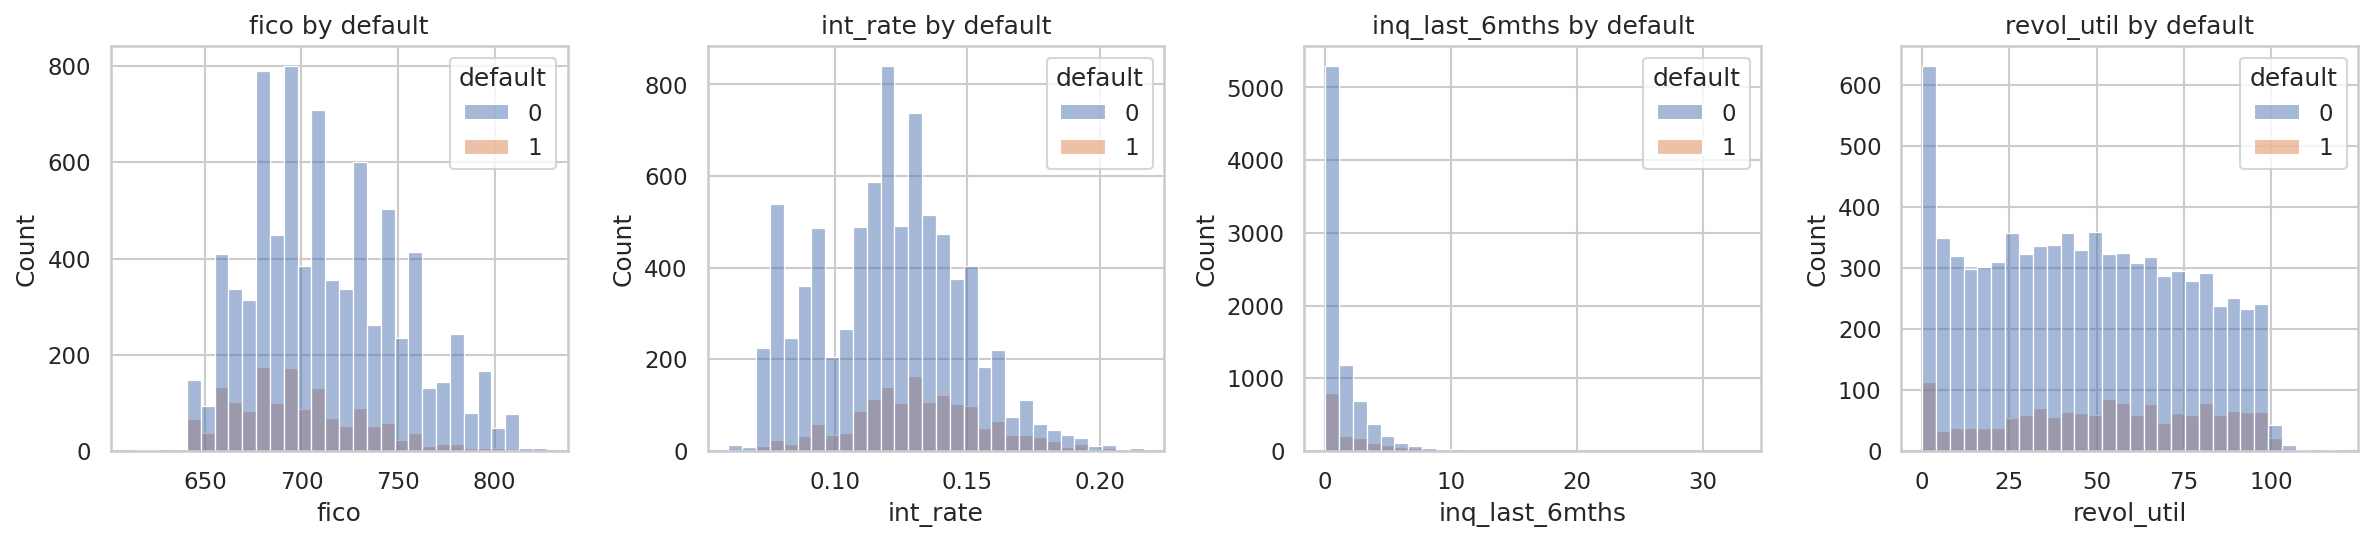

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, col in zip(axes, ["fico", "int_rate", "inq_last_6mths", "revol_util"]):
    sns.histplot(data=df, x=col, hue="default", bins=30, ax=ax)
    ax.set_title(f"{col} by default")
plt.tight_layout(); save_fig("fig_hist_target"); plt.show()

### 2d. Two-variable summaries: default rate **and ROIC** by segment
**Prompt:** *Show default rate and ROIC by FICO band, inquiries, interest-rate quintile, DTI band, loan purpose and credit-policy flag.*

In [7]:
df["fico_band"] = pd.cut(df["fico"], [600, 660, 690, 720, 750, 850], right=False, labels=["<660", "660–689", "690–719", "720–749", "750+"])
df["inq_band"] = pd.cut(df["inq_last_6mths"], [-1, 0, 1, 2, 4, 99], labels=["0", "1", "2", "3–4", "5+"])
df["rate_quintile"] = pd.qcut(df["int_rate"], 5, labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"])
df["dti_band"] = pd.cut(df["dti"], [-1, 5, 10, 15, 20, 30], labels=["0–5", "5–10", "10–15", "15–20", "20–30"])

tables = {k: df.groupby(k, observed=True).apply(kpi) for k in ["fico_band", "inq_band", "rate_quintile", "dti_band", "purpose", "credit_policy"]}
tables["purpose"] = tables["purpose"].sort_values("default_rate")
for k, t in tables.items():
    print("\n", k); display(t.round(3))
print(df.groupby("rate_quintile", observed=True)["int_rate"].agg(["min", "max"]))


 fico_band

 inq_band

 rate_quintile

 dti_band

 purpose

 credit_policy
                  min     max
rate_quintile                
Q1 low         0.0600  0.0963
Q2             0.0964  0.1172
Q3             0.1178  0.1287
Q4             0.1292  0.1442
Q5 high        0.1443  0.2164


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
fico_band,,,,,,
<660,489.0,0.051,0.309,2.690,0.171,0.064
660–689,2758.0,0.288,0.199,19.135,4.229,0.221
690–719,2709.0,0.283,0.169,21.872,4.699,0.215
720–749,1952.0,0.204,0.128,16.945,3.445,0.203
750+,1670.0,0.174,0.074,14.657,3.263,0.223


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
inq_band,,,,,,
0,3637.0,0.380,0.117,29.055,7.477,0.257
1,2462.0,0.257,0.151,19.313,4.238,0.219
2,1384.0,0.144,0.143,11.035,2.627,0.238
3–4,1339.0,0.140,0.218,10.209,1.419,0.139
5+,756.0,0.079,0.323,5.687,0.047,0.008


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
rate_quintile,,,,,,
Q1 low,1990.0,0.208,0.067,12.477,2.512,0.201
Q2,1848.0,0.193,0.152,14.967,2.682,0.179
Q3,1960.0,0.205,0.155,16.651,3.861,0.232
Q4,1875.0,0.196,0.195,14.488,2.998,0.207
Q5 high,1905.0,0.199,0.236,16.715,3.755,0.225


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
dti_band,,,,,,
0–5,1601.0,0.167,0.143,11.694,2.171,0.186
5–10,2012.0,0.210,0.153,15.709,3.257,0.207
10–15,2271.0,0.237,0.155,18.548,4.047,0.218
15–20,2067.0,0.216,0.168,16.847,3.691,0.219
20–30,1627.0,0.170,0.183,12.502,2.642,0.211


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
purpose,,,,,,
major_purchase,437.0,0.046,0.112,2.694,0.517,0.192
credit_card,1262.0,0.132,0.116,10.017,2.605,0.260
debt_consolidation,3957.0,0.413,0.152,34.704,8.691,0.250
all_other,2331.0,0.243,0.166,14.356,2.636,0.184
home_improvement,629.0,0.066,0.170,5.306,0.853,0.161
educational,343.0,0.036,0.201,1.872,0.205,0.110
small_business,619.0,0.065,0.278,6.351,0.301,0.047


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
credit_policy,,,,,,
0,1868.0,0.195,0.278,12.914,0.876,0.068
1,7710.0,0.805,0.132,62.386,14.932,0.239


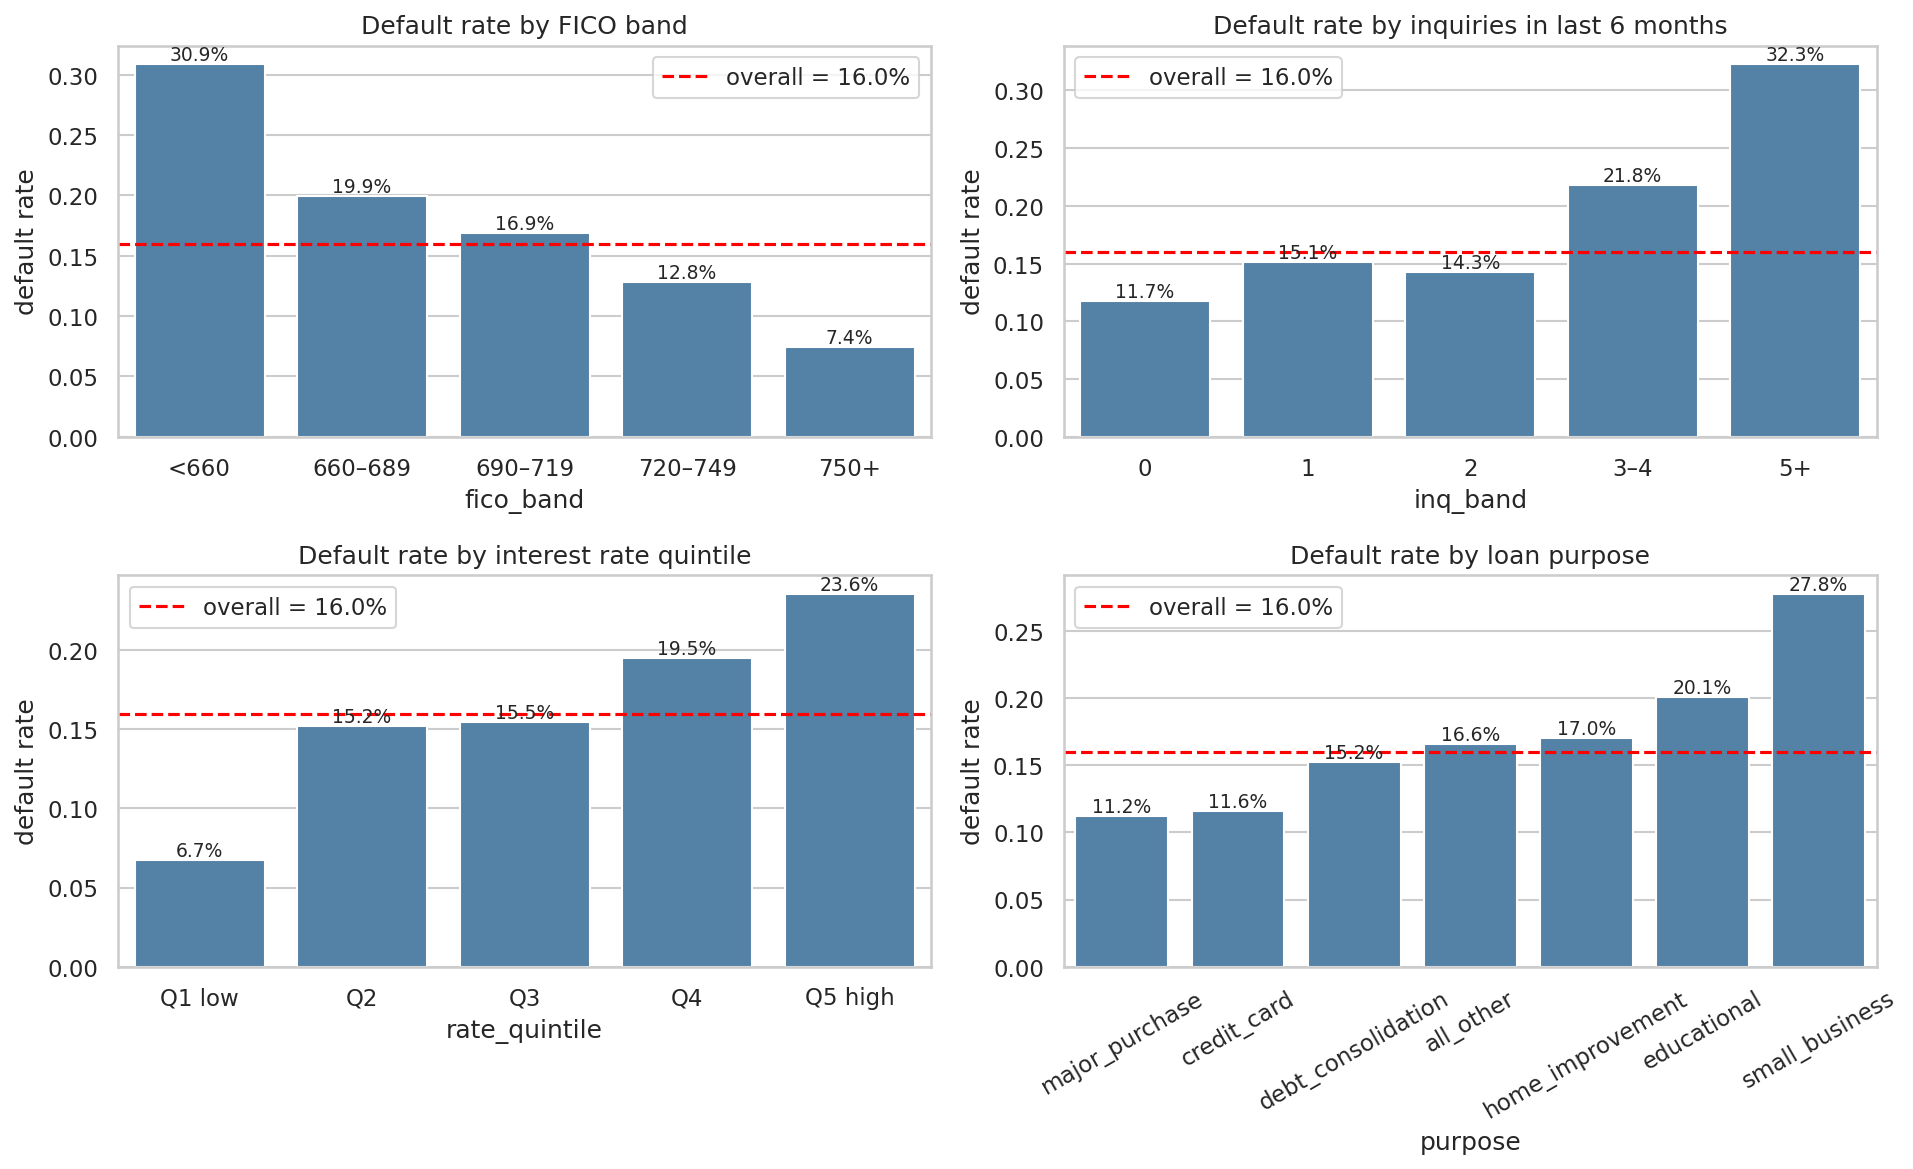

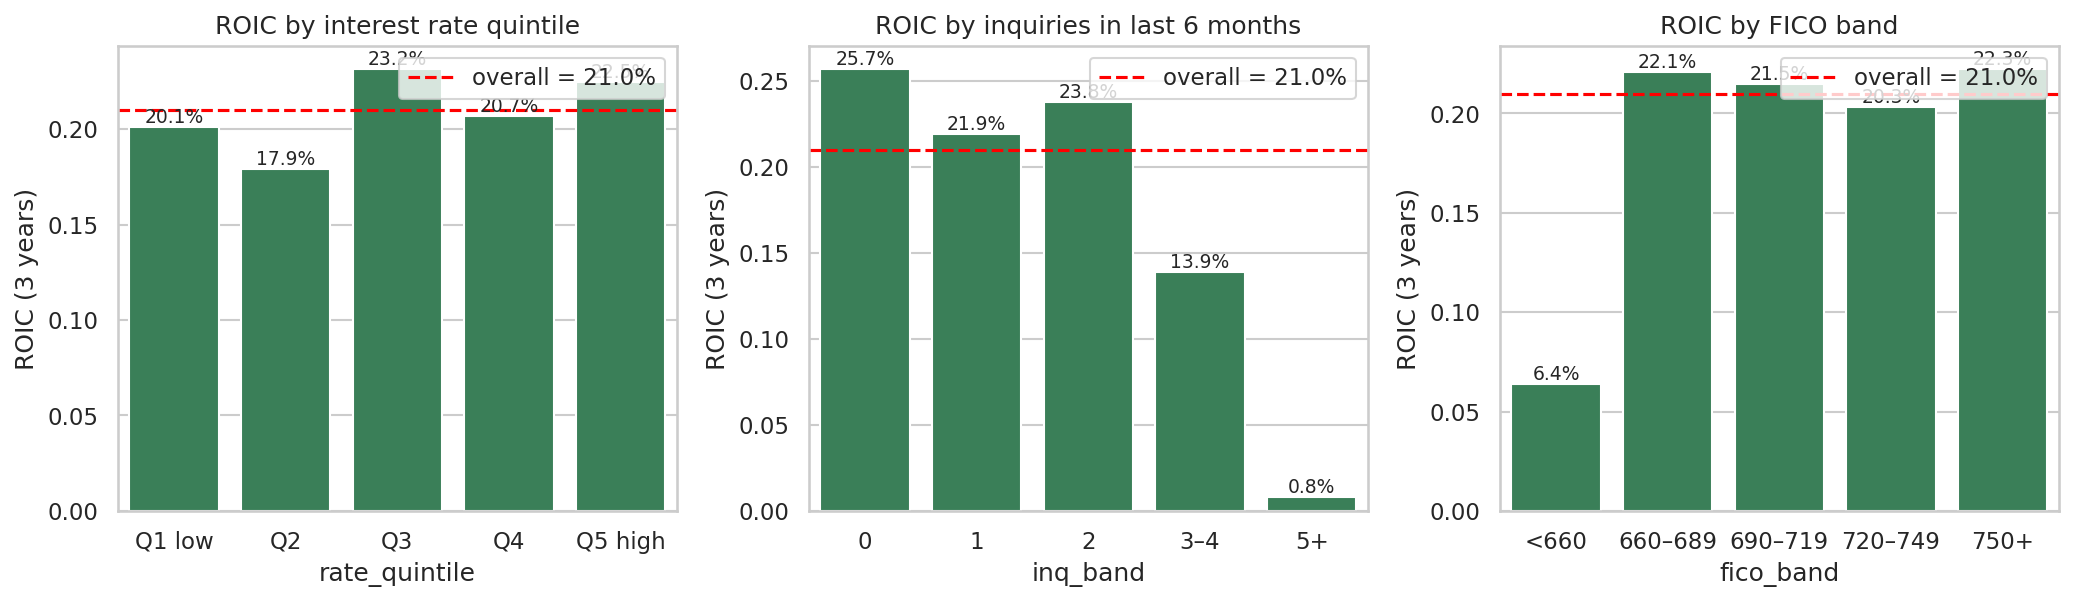

,loans,default_rate,roic
purpose,,,
major_purchase,437.0,0.112,0.192
credit_card,1262.0,0.116,0.260
debt_consolidation,3957.0,0.152,0.250
all_other,2331.0,0.166,0.184
home_improvement,629.0,0.170,0.161
educational,343.0,0.201,0.110
small_business,619.0,0.278,0.047


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (k, title) in zip(axes.flat, [("fico_band", "Default rate by FICO band"), ("inq_band", "Default rate by inquiries in last 6 months"),
                                      ("rate_quintile", "Default rate by interest rate quintile"), ("purpose", "Default rate by loan purpose")]):
    t = tables[k].reset_index()
    t[k] = t[k].astype(str)
    sns.barplot(data=t, x=k, y="default_rate", ax=ax, color="steelblue")
    ax.axhline(base_rate, color="red", linestyle="--", label=f"overall = {base_rate:.1%}")
    ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in t["default_rate"]], fontsize=9)
    ax.set_title(title); ax.set_ylabel("default rate"); ax.legend(loc="upper right" if k == "fico_band" else "upper left")
    if k == "purpose": ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); save_fig("fig_default_by_segment"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (k, title) in zip(axes, [("rate_quintile", "ROIC by interest rate quintile"), ("inq_band", "ROIC by inquiries in last 6 months"), ("fico_band", "ROIC by FICO band")]):
    t = tables[k].reset_index(); t[k] = t[k].astype(str)
    sns.barplot(data=t, x=k, y="roic", ax=ax, color="seagreen")
    ax.axhline(portfolio["roic"], color="red", linestyle="--", label=f"overall = {portfolio['roic']:.1%}")
    ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in t["roic"]], fontsize=9)
    ax.set_title(title); ax.set_ylabel("ROIC (3 years)"); ax.legend(loc="upper right")
plt.tight_layout(); save_fig("fig_roic_by_segment"); plt.show()
snap(tables["purpose"][["loans", "default_rate", "roic"]].round(3), "tbl_purpose")

**Simpson's paradox check:** loans outside the credit policy default about twice as often. Is that only because their FICO scores are lower?

**Prompt:** *Cross-tab default rate by FICO band and credit policy, and compare the average profile of the two policy groups.*

In [9]:
simpson = df.pivot_table(index="fico_band", columns="credit_policy", values="default", aggfunc=["mean", "size"], observed=True)
snap(simpson.round(3), "tbl_simpson")
display(df.groupby("credit_policy")[["fico", "int_rate", "inq_last_6mths", "revol_util", "dti"]].mean().round(2))

mean        size      
credit_policy      0      1    0     1
fico_band                             
<660           0.310  0.000  487     2
660–689        0.287  0.172  662  2096
690–719        0.269  0.149  458  2251
720–749        0.236  0.115  212  1740
750+           0.102  0.073   49  1621

,fico,int_rate,inq_last_6mths,revol_util,dti
credit_policy,,,,,
0,683.98,0.14,3.97,52.93,13.88
1,717.36,0.12,1.00,45.31,12.30


**Prompt:** *Show me the correlations between the numerical variables using a heatmap.*

credit_policy       -0.158
fico                -0.150
log_annual_inc      -0.033
days_with_cr_line   -0.029
delinq_2yrs          0.009
dti                  0.037
pub_rec              0.049
installment          0.050
revol_bal            0.054
revol_util           0.082
inq_last_6mths       0.149
int_rate             0.160
Name: default, dtype: float64
FICO vs rate: -0.71 | revol_bal vs revol_util: 0.2


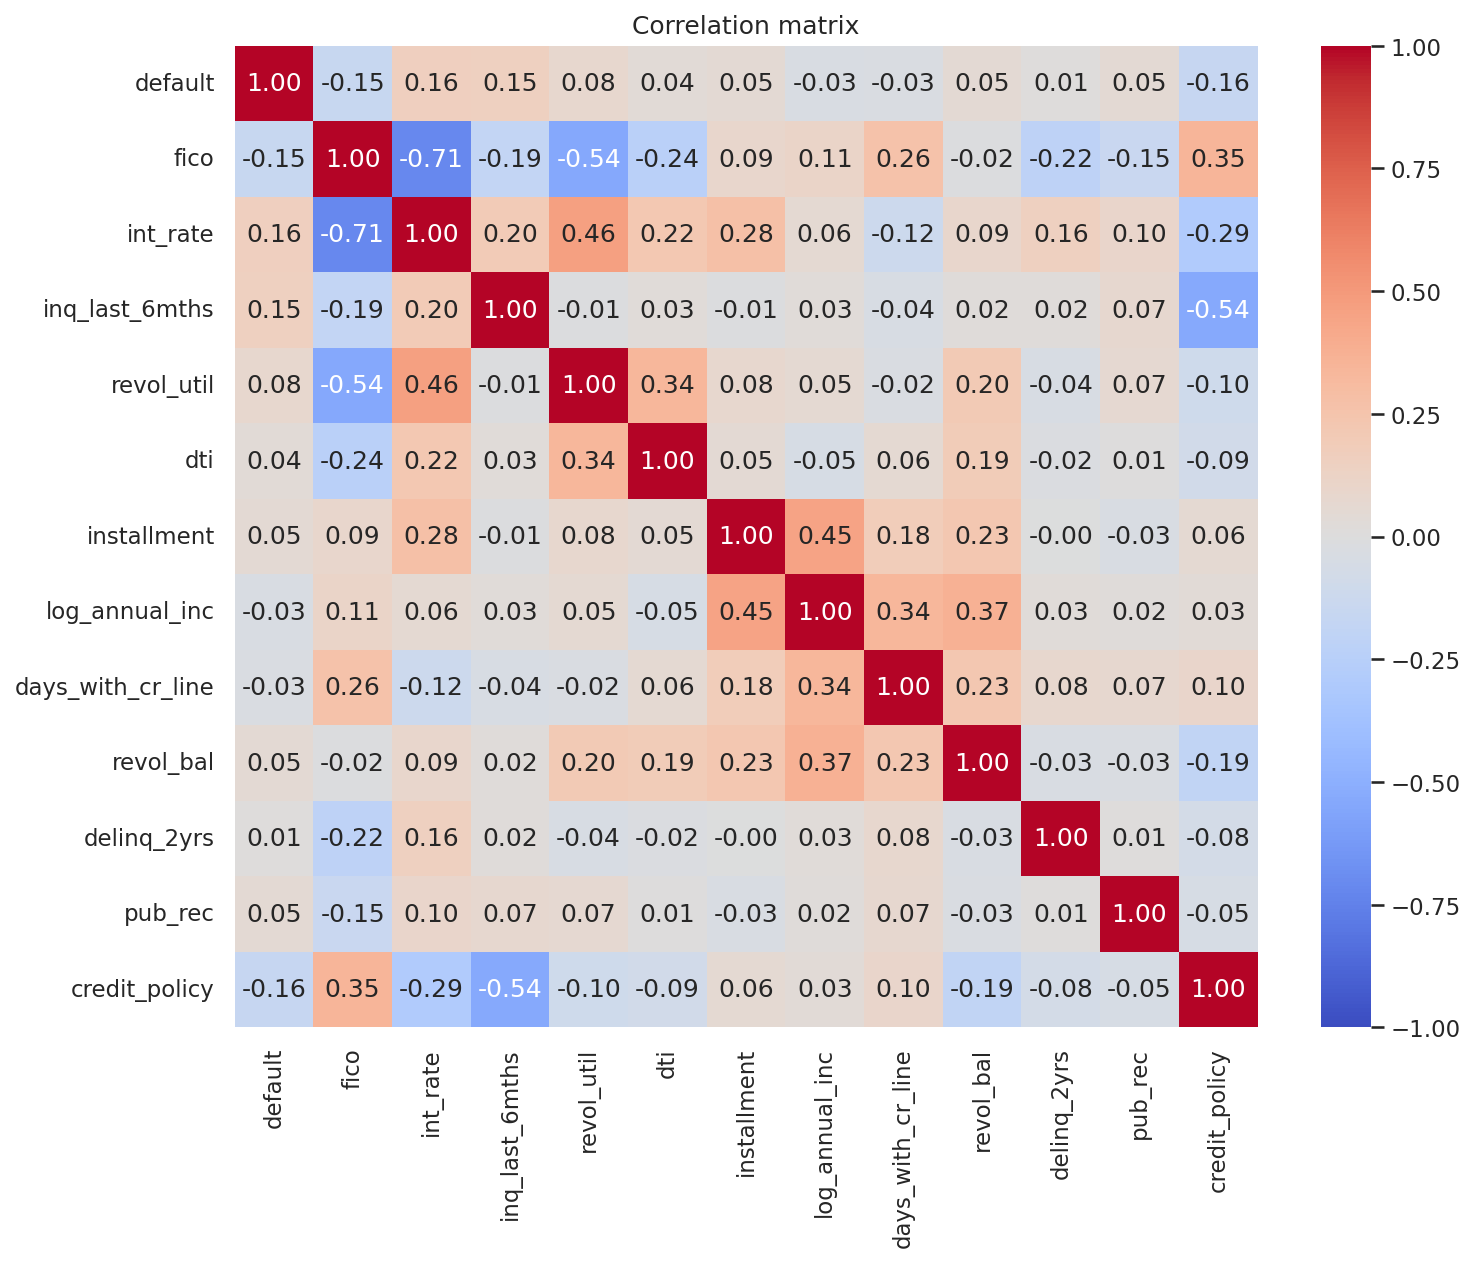

In [10]:
corr_cols = ["default", "fico", "int_rate", "inq_last_6mths", "revol_util", "dti", "installment", "log_annual_inc",
             "days_with_cr_line", "revol_bal", "delinq_2yrs", "pub_rec", "credit_policy"]
C = df[corr_cols].corr()
plt.figure(figsize=(11, 8.5))
sns.heatmap(C, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix")
save_fig("fig_corr_heatmap"); plt.show()
print(C["default"].drop("default").sort_values().round(3))
print("FICO vs rate:", round(C.loc["fico", "int_rate"], 2), "| revol_bal vs revol_util:", round(C.loc["revol_bal", "revol_util"], 2))

**What the descriptive statistics say**

| | Hypothesis | Verdict |
|---|---|---|
| H1 | Lower FICO → more default | **Supported.** 31% below 660 vs 7% at 750+ |
| H2 | More inquiries → more default | **Strongly supported.** 12% at 0 inquiries vs 32% at 5+. ROIC collapses to ~1% at 5+ |
| H3 | Higher rate → more default | **Supported for default** (7% → 24% across quintiles), but **ROIC is flat at 18–23%**: pricing largely compensates |
| H4 | Small business riskier | **Supported.** 28% default, ROIC only 5% (vs 25–26% for debt consolidation and credit cards) |
| H5 | Higher DTI → more default | **Weak.** 14% → 18% across DTI bands; r = 0.04 |

**Most important features for profitability:** inquiries, FICO, purpose and the credit-policy flag. These separate *profit* as well as default. Interest rate predicts default but is already priced in.

**Correlations:** FICO and interest rate are strongly linked (r = −0.71, since Lending Club prices on FICO). Revolving utilization also tracks FICO (−0.54) and rate (+0.46). Revolving *balance* and *utilization* are only weakly related (r = 0.20). Inquiries relate to the policy flag (−0.54). No single variable correlates with default above |0.16|.

**Simpson check:** the credit-policy gap holds within every FICO band (e.g. 660–689: 29% vs 17%), so there is no reversal. The policy flag carries information beyond FICO, mainly inquiries (4.0 vs 1.0).

## 3. K-Means clustering
**Choosing the variables.** We cluster on the 8 application-time numeric variables an underwriter sees: FICO, interest rate, installment, log income, DTI, revolving utilization, inquiries (6m), credit-history length. All are standardized (z-scores), so no variable dominates because of its units.

Excluded, and why:
- `default`, `tot_payment`, `principal`, `interest`: outcome or post-outcome fields. Segments should be formed without the answer and then *checked* against it.
- `credit_policy`: Lending Club's own screening decision. Clustering on it would just re-create their screen.
- `delinq_2yrs`, `pub_rec`: 88–94% zeros. In Euclidean distance the rare non-zeros form outlier clusters.
- `revol_bal`: we tested adding log balance. It produced an artifact cluster of ~670 zero-balance borrowers and lowered the silhouette score, so we left it out. It also overlaps with utilization and income.
- `purpose`: categorical. We profile it after clustering instead.

**Prompt:** *Standardize the chosen variables, run K-Means for k = 2–10, and plot the elbow (within-cluster SS) and silhouette score.*

With log revol_bal, k=4 silhouette: 0.164
   loans  median_revol_bal  default_rate
c                                       
0    674               6.0         0.180
1   2775            6103.0         0.085
2   2420           22165.5         0.195
3   3709            7370.0         0.190
Stability, adjusted Rand index across 5 other seeds: [0.957 0.987 0.972 0.965 0.958]


,k,within_SS,silhouette,wss_drop_pct
0,2,60970.0,0.194,NaN
1,3,53633.0,0.170,12.0
2,4,49430.0,0.172,7.8
3,5,45795.0,0.145,7.4
4,6,43303.0,0.136,5.4
5,7,41178.0,0.139,4.9
6,8,39194.0,0.137,4.8
7,9,37635.0,0.134,4.0
8,10,36406.0,0.127,3.3


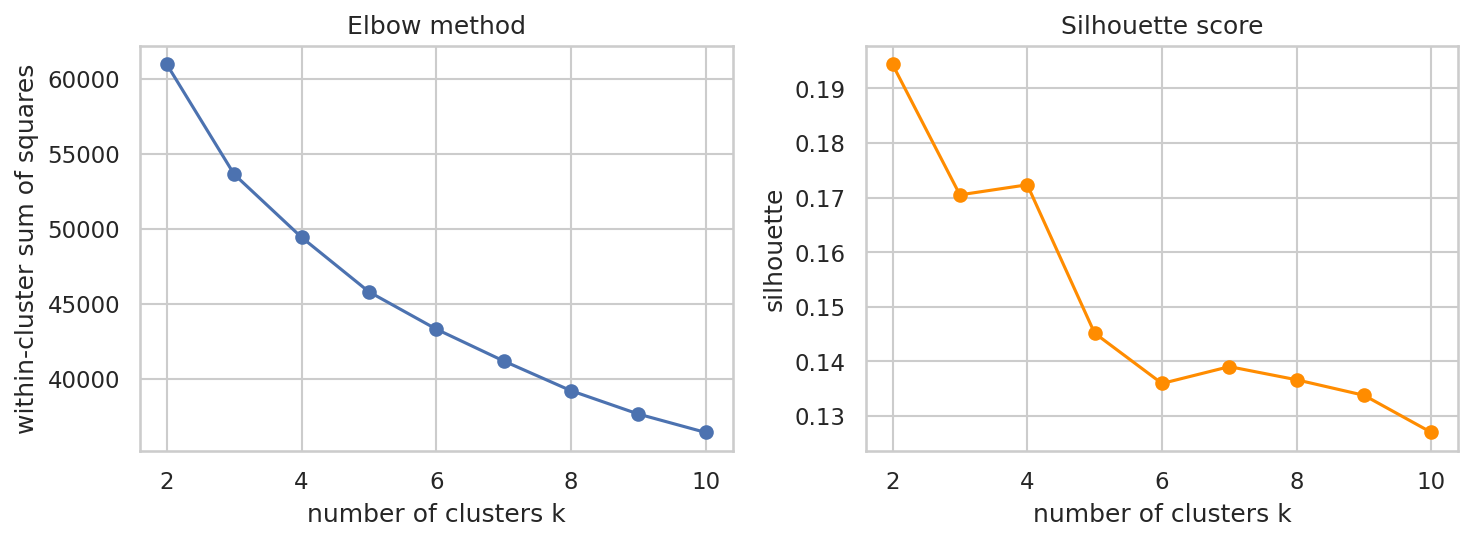

In [11]:
KM_VARS = ["fico", "int_rate", "installment", "log_annual_inc", "dti", "revol_util", "inq_last_6mths", "days_with_cr_line"]
KM_LABELS = ["FICO", "Interest rate", "Installment", "Log income", "DTI", "Revol. utilization", "Inquiries 6m", "Credit history"]
Xk = StandardScaler().fit_transform(df[KM_VARS])
ks, wss, sil = list(range(2, 11)), [], []
for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xk)
    wss.append(m.inertia_); sil.append(silhouette_score(Xk, m.labels_, sample_size=5000, random_state=SEED))
k_diag = pd.DataFrame({"k": ks, "within_SS": np.round(wss), "silhouette": np.round(sil, 3),
                       "wss_drop_pct": np.r_[np.nan, -np.diff(wss)/np.array(wss[:-1])*100].round(1)})
snap(k_diag, "tbl_k_diag")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(ks, wss, "o-"); axes[0].set_title("Elbow method"); axes[0].set_xlabel("number of clusters k"); axes[0].set_ylabel("within-cluster sum of squares")
axes[1].plot(ks, sil, "o-", color="darkorange"); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("number of clusters k"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); save_fig("fig_k_selection"); plt.show()

# Test of the alternative variable set (adding log revolving balance)
Xalt = StandardScaler().fit_transform(df[KM_VARS].assign(log_revol_bal=np.log1p(df["revol_bal"])))
alt = KMeans(n_clusters=4, n_init=20, random_state=SEED).fit(Xalt)
print("With log revol_bal, k=4 silhouette:", round(silhouette_score(Xalt, alt.labels_, sample_size=5000, random_state=SEED), 3))
print(df.assign(c=alt.labels_).groupby("c").agg(loans=("default", "size"), median_revol_bal=("revol_bal", "median"), default_rate=("default", "mean")).round(3))

K = 4
ref = KMeans(n_clusters=K, n_init=20, random_state=SEED).fit(Xk).labels_
ari = [adjusted_rand_score(ref, KMeans(n_clusters=K, n_init=20, random_state=s).fit(Xk).labels_) for s in [1, 7, 42, 2026, 99]]
print("Stability, adjusted Rand index across 5 other seeds:", np.round(ari, 3))

**Choosing k = 4**
- **Elbow:** there is no sharp bend. Each extra cluster cuts within-cluster SS by 12% (k = 3), 8% (k = 4), 7% (k = 5), then about 5% or less. The elbow alone doesn't settle k.
- **Silhouette:** k = 2 is highest (0.19) but only splits prime from non-prime, which is too coarse to act on. k = 4 edges out k = 3 (0.172 vs 0.170) and isolates a distinct high-risk group. At k = 5 the score drops to 0.145.
- **Stability:** k = 4 reproduces the same segments from different random starts (ARI ≥ 0.95).
- **Business test:** k = 5 splits a mid-risk group by utilization with little difference in default or ROIC. That adds complexity without adding a decision.

**Prompt:** *Fit k = 4, plot the standardized cluster centers as a parallel-lines plot, and profile each cluster (size, means, default rate, ROIC, purpose mix, prototype loan closest to the center).*

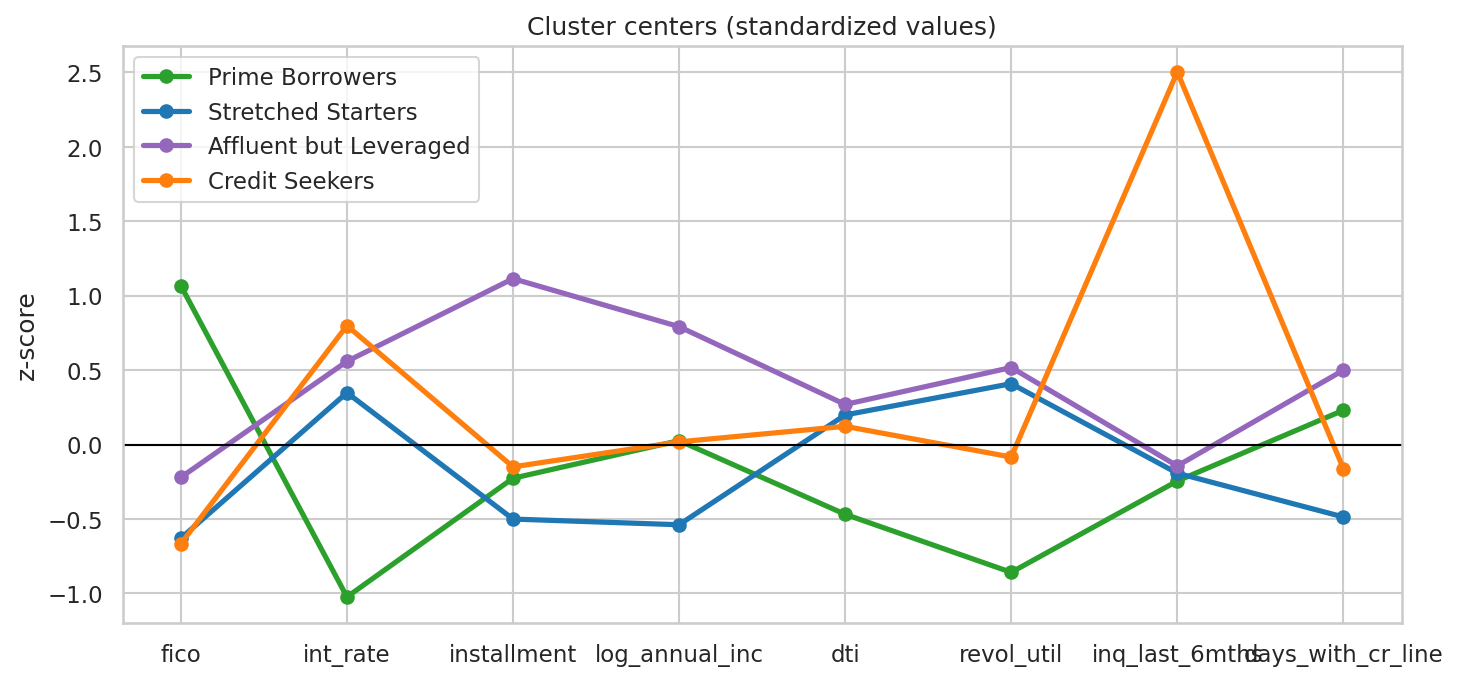

,fico,int_rate,installment,log_annual_inc,dti,revol_util,inq_last_6mths,days_with_cr_line
Prime Borrowers,1.07,-1.02,-0.23,0.03,-0.47,-0.86,-0.24,0.23
Stretched Starters,-0.63,0.35,-0.50,-0.54,0.20,0.41,-0.19,-0.49
Affluent but Leveraged,-0.22,0.56,1.11,0.79,0.27,0.52,-0.14,0.50
Credit Seekers,-0.67,0.80,-0.15,0.02,0.12,-0.08,2.50,-0.16


,fico,int_rate,installment,annual_inc,dti,revol_util,inq_last_6mths,credit_yrs,revol_bal,credit_policy
segment,,,,,,,,,,
Prime Borrowers,751.346,0.095,272.188,68483.321,9.380,21.887,1.038,14.060,11398.533,0.950
Stretched Starters,686.954,0.132,215.566,44960.464,13.974,58.649,1.154,9.164,10550.705,0.803
Affluent but Leveraged,702.469,0.138,550.111,105124.671,14.453,61.806,1.261,15.901,34880.415,0.848
Credit Seekers,685.571,0.144,287.608,66485.132,13.468,44.412,7.090,11.383,13923.020,0.051


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
segment,,,,,,
Prime Borrowers,3014.0,0.315,0.085,21.974,4.693,0.214
Stretched Starters,3561.0,0.372,0.179,18.547,4.186,0.226
Affluent but Leveraged,2303.0,0.240,0.180,30.099,6.895,0.229
Credit Seekers,700.0,0.073,0.324,4.679,0.034,0.007


,loans,share_of_loans,default_rate,roic,fico,int_rate,annual_inc,revol_util,inq_last_6mths
segment,,,,,,,,,
Prime Borrowers,3014.0,0.315,0.085,0.214,751.346,0.095,68483.321,21.887,1.038
Stretched Starters,3561.0,0.372,0.179,0.226,686.954,0.132,44960.464,58.649,1.154
Affluent but Leveraged,2303.0,0.240,0.180,0.229,702.469,0.138,105124.671,61.806,1.261
Credit Seekers,700.0,0.073,0.324,0.007,685.571,0.144,66485.132,44.412,7.090


,loans,default_rate,net_profit_$M,roic
all loans,9578.0,0.160,15.808,0.210
without Credit Seekers,8878.0,0.147,15.774,0.223


purpose,all_other,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business
segment,,,,,,,
Prime Borrowers,31.0,12.0,30.0,4.0,9.0,7.0,6.0
Stretched Starters,25.0,13.0,45.0,4.0,4.0,4.0,4.0
Affluent but Leveraged,13.0,16.0,52.0,1.0,6.0,2.0,11.0
Credit Seekers,27.0,11.0,35.0,5.0,9.0,5.0,8.0


,fico,int_rate,installment,annual_inc,dti,revol_util,inq_last_6mths,credit_yrs,purpose,default
segment,,,,,,,,,,
Prime Borrowers,752,0.093,297.11,54996.0,12.15,24.7,1,12.238,debt_consolidation,0
Stretched Starters,677,0.135,254.42,47900.0,13.23,51.0,1,8.706,debt_consolidation,0
Affluent but Leveraged,692,0.139,546.20,89100.0,16.51,60.9,0,15.852,credit_card,0
Credit Seekers,687,0.150,388.04,47000.0,16.09,37.2,6,10.697,debt_consolidation,1


In [12]:
km = KMeans(n_clusters=K, n_init=20, random_state=SEED).fit(Xk)
df["cluster"] = km.labels_
means = df.groupby("cluster")[["fico", "annual_inc", "inq_last_6mths"]].mean()
names, left = {}, set(means.index)
for trait, name, fn in [("inq_last_6mths", "Credit Seekers", "idxmax"), ("fico", "Prime Borrowers", "idxmax"), ("annual_inc", "Affluent but Leveraged", "idxmax")]:
    c = getattr(means.loc[list(left), trait], fn)(); names[c] = name; left.remove(c)
names[left.pop()] = "Stretched Starters"
df["segment"] = df["cluster"].map(names)
ORDER = ["Prime Borrowers", "Stretched Starters", "Affluent but Leveraged", "Credit Seekers"]

centers = pd.DataFrame(km.cluster_centers_, columns=KM_VARS).rename(index=names).loc[ORDER]
plt.figure(figsize=(11, 5))
for seg in ORDER:
    plt.plot(KM_VARS, centers.loc[seg], marker="o", linewidth=2.5, label=seg, color=SEG_COLORS[seg])
plt.axhline(0, color="black", linewidth=1)
plt.title("Cluster centers (standardized values)"); plt.ylabel("z-score"); plt.legend()
save_fig("fig_parallel_centers"); plt.show()
snap(centers.round(2), "tbl_centers")

profile = df.groupby("segment")[["fico", "int_rate", "installment", "annual_inc", "dti", "revol_util", "inq_last_6mths",
                                  "credit_yrs", "revol_bal", "credit_policy"]].mean().loc[ORDER]
seg_kpi = df.groupby("segment").apply(kpi).loc[ORDER]
display(profile.round(3)); display(seg_kpi.round(3))
seg_summary = seg_kpi[["loans", "share_of_loans", "default_rate", "roic"]].join(profile[["fico", "int_rate", "annual_inc", "revol_util", "inq_last_6mths"]])
snap(seg_summary.round(3), "tbl_segments")
keep = df["segment"] != "Credit Seekers"
what_if = pd.DataFrame({"all loans": kpi(df), "without Credit Seekers": kpi(df[keep])}).T[["loans", "default_rate", "net_profit_$M", "roic"]]
snap(what_if.round(3), "tbl_what_if")
purpose_mix = pd.crosstab(df["segment"], df["purpose"], normalize="index").loc[ORDER]
display((purpose_mix*100).round(0))

df["dist_to_center"] = np.linalg.norm(Xk - km.cluster_centers_[df["cluster"]], axis=1)
prototypes = df.loc[df.groupby("segment")["dist_to_center"].idxmin().loc[ORDER],
                    ["segment", "fico", "int_rate", "installment", "annual_inc", "dti", "revol_util", "inq_last_6mths", "credit_yrs", "purpose", "default"]].set_index("segment")
snap(prototypes.round(3), "tbl_prototypes")

### Naming the clusters

| Segment | Share | Default | ROIC | Distinguishing features (from the parallel-lines plot) |
|---|---|---|---|---|
| **Prime Borrowers** | 31% | 8.5% | 21.4% | FICO far above average (~751), lowest rates (9.5%), low utilization (22%) and DTI. Safest, but low rates cap the return. |
| **Stretched Starters** | 37% | 17.9% | 22.6% | Below-average FICO (~687), lowest income (~\$45K), short credit history (9 yrs), high utilization (59%), small loans. |
| **Affluent but Leveraged** | 24% | 18.0% | 22.9% | Highest income (~\$105K), long history, but the largest loans (\$550/mo), \$35K revolving balances and 62% utilization. Income doesn't buy lower risk. |
| **Credit Seekers** | 7% | 32.4% | **0.7%** | Inquiries 2.5 SD above average (~7 in 6 months), highest rate (14.4%), 95% outside the credit policy. Default losses wipe out the interest. |

**How this clustering guides modeling**
- **Screening signal:** Credit Seekers are 7% of loans but earn essentially zero return. Dropping them would raise portfolio ROIC from 21.0% to 22.3% with almost no change in net profit (\$15.81M → \$15.77M). That is a concrete starting point for the Update 3 threshold trade-off, and the CMO keeps 93% of volume.
- **Features:** inquiries and the FICO/rate/utilization block define the segments. Use them in the logistic regression. Consider the segment label or interactions (e.g. income × utilization) as features.
- **Where a model must work hardest:** the two mid-risk segments (61% of loans, ~18% default, but profitable at ~22–23% ROIC). Blanket rejection would destroy profit and market share, so the model needs to separate good from bad *within* them.
- **Pricing insight for the CFO:** Prime Borrowers have the lowest default but *not* the highest ROIC. Risk-based pricing is working in the middle tiers and failing only for the Credit Seekers.

## 4. Principal Component Analysis
**Choosing the variables (11):** interest rate, installment, log income, DTI, FICO, credit history, **log** revolving balance, revolving utilization, inquiries, delinquencies, public records. PCA handles sparse counts better than K-Means because it summarizes shared variance and doesn't build groups from distances. Excluded: the target and post-outcome KPI fields, `credit_policy` (Lending Club's own decision) and `purpose` (categorical). All variables are standardized.

**Prompt:** *Run PCA on the standardized variables and show a scree plot with cumulative variance explained.*

Eigenvalue > 1 (Kaiser): 5 | PCs for 80% / 90%: 7 / 8


,PC,eigenvalue,var_explained_pct,cumulative_pct
0,PC1,2.59,23.6,23.6
1,PC2,1.93,17.5,41.1
2,PC3,1.28,11.6,52.7
3,PC4,1.04,9.4,62.2
4,PC5,1.01,9.2,71.3
5,PC6,0.90,8.2,79.5
6,PC7,0.72,6.6,86.1
7,PC8,0.58,5.2,91.3
8,PC9,0.47,4.2,95.5
9,PC10,0.31,2.8,98.3


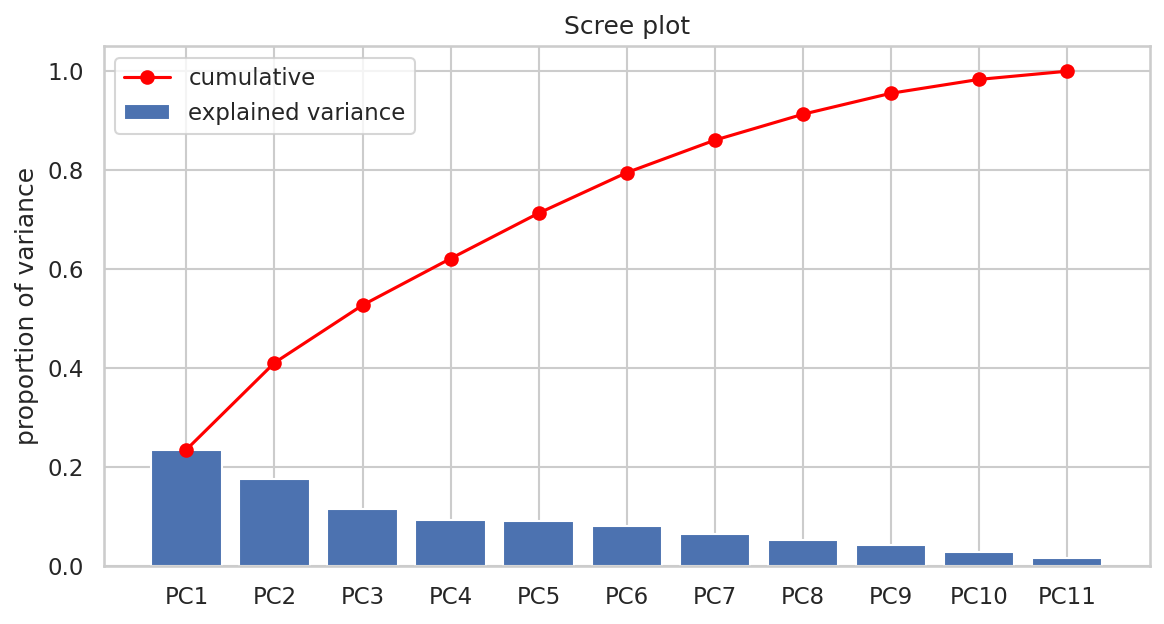

In [13]:
df["log_revol_bal"] = np.log1p(df["revol_bal"])
PCA_VARS = ["int_rate", "installment", "log_annual_inc", "dti", "fico", "days_with_cr_line", "log_revol_bal", "revol_util", "inq_last_6mths", "delinq_2yrs", "pub_rec"]
PCA_LABELS = ["Interest rate", "Installment", "Log income", "DTI", "FICO", "Credit history", "Log revol. balance", "Revol. utilization", "Inquiries 6m", "Delinq. 2y", "Public records"]
Xp = StandardScaler().fit_transform(df[PCA_VARS])
pca = PCA(random_state=SEED).fit(Xp)
evr, eig = pca.explained_variance_ratio_, pca.explained_variance_
scree = pd.DataFrame({"PC": [f"PC{i+1}" for i in range(len(evr))], "eigenvalue": eig.round(2),
                      "var_explained_pct": (evr*100).round(1), "cumulative_pct": (evr.cumsum()*100).round(1)})
display(scree)
print("Eigenvalue > 1 (Kaiser):", int((eig > 1).sum()), "| PCs for 80% / 90%:", int(np.argmax(evr.cumsum() >= .8) + 1), "/", int(np.argmax(evr.cumsum() >= .9) + 1))
plt.figure(figsize=(9, 4.5))
plt.bar(scree.PC, evr, label="explained variance")
plt.plot(scree.PC, evr.cumsum(), "o-", color="red", label="cumulative")
plt.title("Scree plot"); plt.ylabel("proportion of variance"); plt.legend()
save_fig("fig_scree"); plt.show()

**Prompt:** *Show the loadings of the first four components and name each component (model-driven interpretation).*

,PC1,PC2,PC3,PC4
Interest rate,0.49,-0.14,0.27,-0.19
Installment,0.17,0.44,0.26,-0.35
Log income,0.10,0.54,0.28,-0.07
DTI,0.31,0.03,-0.38,0.15
FICO,-0.49,0.33,-0.12,0.01
Credit history,-0.02,0.48,0.09,0.39
Log revol. balance,0.33,0.37,-0.33,0.07
Revol. utilization,0.49,0.01,-0.29,0.02
Inquiries 6m,0.12,-0.12,0.39,0.12
Delinq. 2y,0.09,-0.07,0.48,-0.00


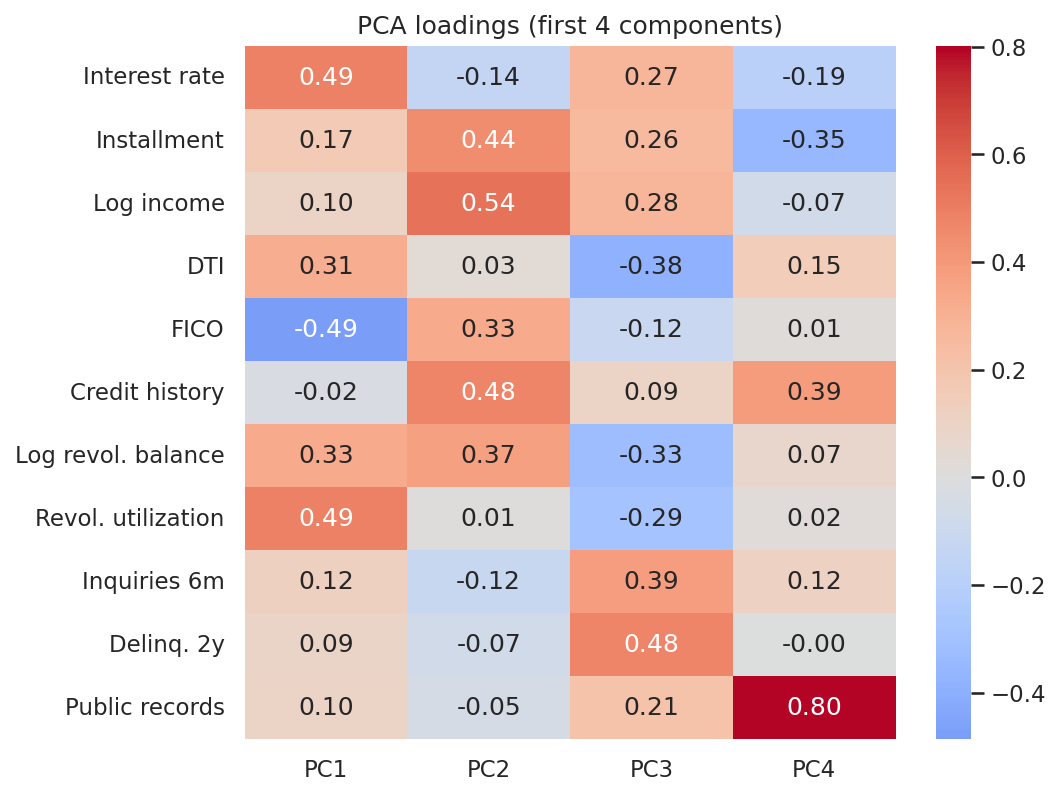

In [14]:
N_PC = 4
loadings = pd.DataFrame(pca.components_[:N_PC].T, index=PCA_LABELS, columns=[f"PC{i+1}" for i in range(N_PC)])
display(loadings.round(2))
plt.figure(figsize=(7, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PCA loadings (first 4 components)")
save_fig("fig_loadings"); plt.show()
PC_NAMES = {"PC1": "Credit risk & leverage", "PC2": "Financial capacity & maturity", "PC3": "Recent credit stress", "PC4": "Public-record flag"}

**Model-driven interpretation** (a loading above about |0.3| is a strong contributor)
- **PC1, Credit risk & leverage (24%):** + interest rate (0.49), + utilization (0.49), + log balance (0.33), + DTI (0.31), − FICO (−0.49).
- **PC2, Financial capacity & maturity (18%):** + income (0.54), + credit history (0.48), + installment (0.44), + log balance (0.37), + FICO (0.33).
- **PC3, Recent credit stress (12%):** + delinquencies (0.48), + inquiries (0.39), + rate (0.27), against lower DTI and utilization.
- **PC4, Public-record flag (9%):** public records (0.80).

**Prompt:** *Draw a biplot of PC1 vs PC2 with loans colored by default and loading arrows. Label the most extreme loans on each axis and show their raw values (data-driven interpretation). Show default rate and ROIC by PC1 quintile.*

,PC1,PC2,fico,int_rate,revol_util,annual_inc,credit_yrs,revol_bal,default
A: max PC1,4.57,3.50,672,0.20,99.0,600000.00,20.86,952013,0
B: min PC1,-4.90,-0.63,797,0.07,0.5,80000.00,12.16,0,0
C: max PC2,-2.84,5.19,807,0.08,12.9,1199999.99,32.03,7729,0
D: min PC2,-3.70,-6.06,702,0.09,0.0,2000.00,0.65,0,1


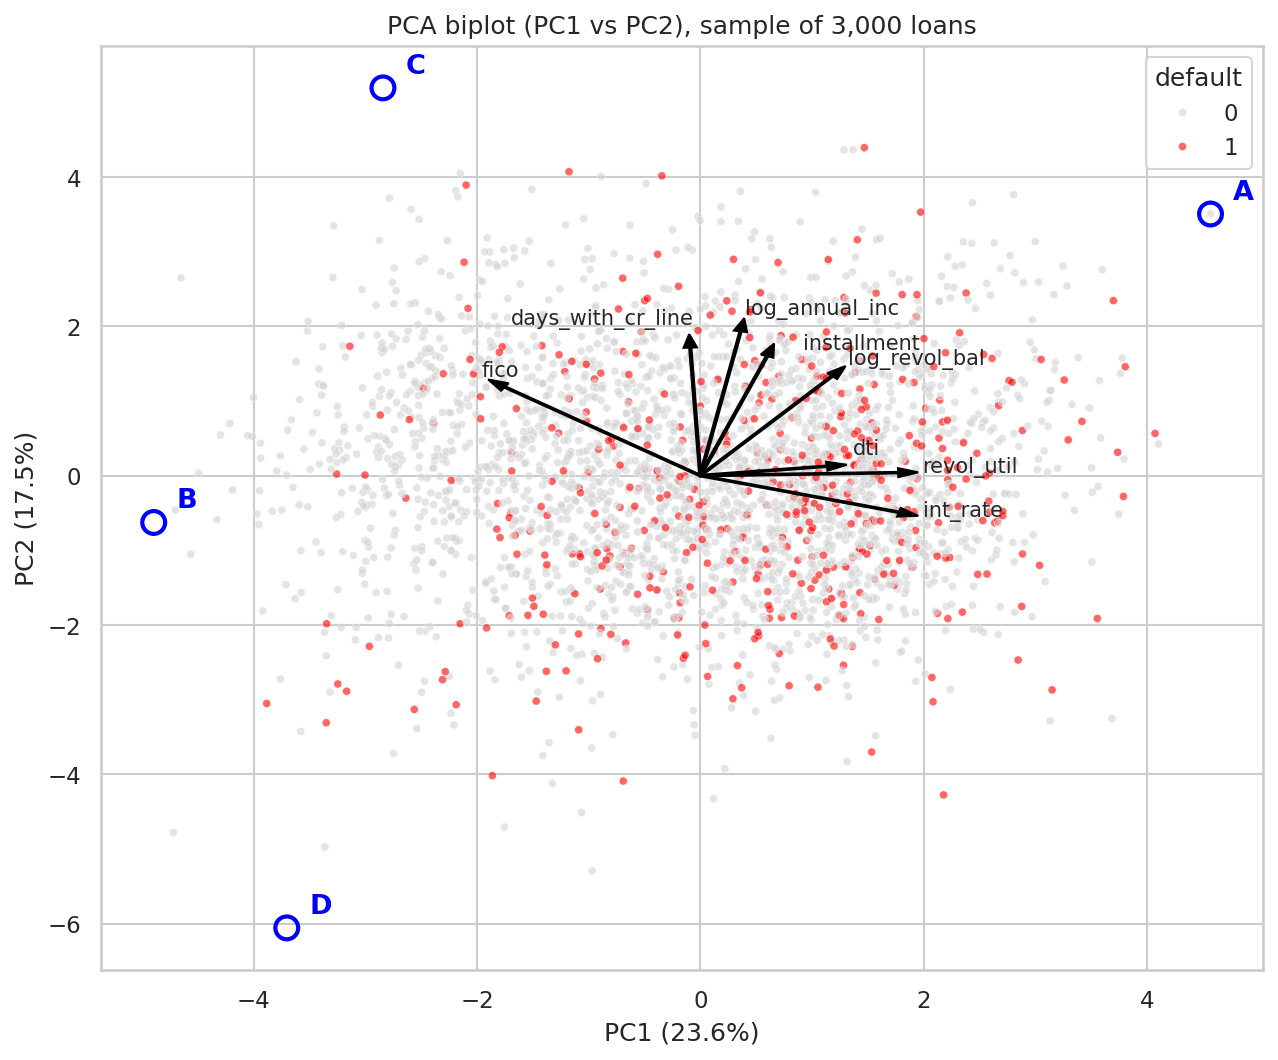

,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
PC1_quintile,,,,,,
Q1 safest,1916.0,0.2,0.084,12.786,2.717,0.213
Q2,1915.0,0.2,0.137,14.589,2.907,0.199
Q3,1916.0,0.2,0.147,14.938,3.676,0.246
Q4,1915.0,0.2,0.199,15.202,2.858,0.188
Q5 riskiest,1916.0,0.2,0.234,17.785,3.650,0.205


,loans,share_of_loans,default_rate,principal_$M,net_profit_$M,roic
PC2_quintile,,,,,,
Q1 low,1916.0,0.2,0.210,7.470,1.182,0.158
Q2,1915.0,0.2,0.169,10.944,2.135,0.195
Q3,1916.0,0.2,0.142,14.010,3.169,0.226
Q4,1915.0,0.2,0.138,18.004,4.020,0.223
Q5 high,1916.0,0.2,0.141,24.871,5.302,0.213


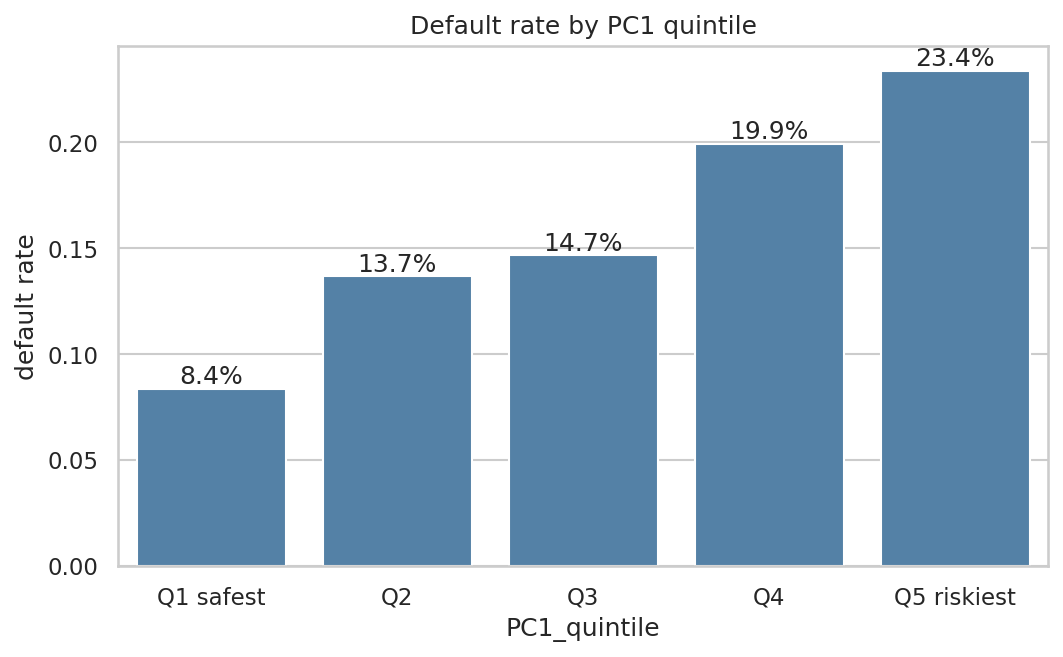

In [15]:
S = pca.transform(Xp); df["PC1"], df["PC2"] = S[:, 0], S[:, 1]
rng = np.random.default_rng(SEED); idx = rng.choice(len(df), 3000, replace=False); samp = df.iloc[idx]
ext_idx = {"A": df["PC1"].idxmax(), "B": df["PC1"].idxmin(), "C": df["PC2"].idxmax(), "D": df["PC2"].idxmin()}
extremes = df.loc[list(ext_idx.values()), ["PC1", "PC2", "fico", "int_rate", "revol_util", "dti", "annual_inc", "installment", "credit_yrs", "revol_bal", "inq_last_6mths", "default"]]
extremes.index = [f"{k}: {'max' if k in 'AC' else 'min'} {'PC1' if k in 'AB' else 'PC2'}" for k in ext_idx]
snap(extremes[["PC1", "PC2", "fico", "int_rate", "revol_util", "annual_inc", "credit_yrs", "revol_bal", "default"]].round(2), "tbl_extremes")

plt.figure(figsize=(10, 8))
sns.scatterplot(data=samp, x="PC1", y="PC2", hue="default", palette={0: "lightgray", 1: "red"}, alpha=0.6, s=15)
scale = 3.6
for lab, v1, v2 in zip(PCA_VARS, pca.components_[0], pca.components_[1]):
    if np.hypot(v1, v2) < .25: continue
    plt.arrow(0, 0, v1*scale, v2*scale, color="black", width=0.02, head_width=0.12)
    dx, dy = {"days_with_cr_line": (-1.6, 0.1), "installment": (0.25, -0.1), "dti": (0.1, 0.15)}.get(lab, (0, 0))  # move overlapping labels
    plt.text(v1*scale*1.12 + dx, v2*scale*1.12 + dy, lab, fontsize=10)
for k, i in ext_idx.items():
    plt.scatter(df.loc[i, "PC1"], df.loc[i, "PC2"], s=120, facecolor="none", edgecolor="blue", linewidth=2)
    plt.text(df.loc[i, "PC1"] + 0.2, df.loc[i, "PC2"] + 0.2, k, fontsize=13, color="blue", fontweight="bold")
plt.title("PCA biplot (PC1 vs PC2), sample of 3,000 loans")
plt.xlabel(f"PC1 ({evr[0]:.1%})"); plt.ylabel(f"PC2 ({evr[1]:.1%})")
save_fig("fig_biplot"); plt.show()

df["PC1_quintile"] = pd.qcut(df["PC1"], 5, labels=["Q1 safest", "Q2", "Q3", "Q4", "Q5 riskiest"])
df["PC2_quintile"] = pd.qcut(df["PC2"], 5, labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"])
by_pc1 = df.groupby("PC1_quintile", observed=True).apply(kpi); by_pc2 = df.groupby("PC2_quintile", observed=True).apply(kpi)
display(by_pc1.round(3)); display(by_pc2.round(3))
t = by_pc1.reset_index(); t["PC1_quintile"] = t["PC1_quintile"].astype(str)
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=t, x="PC1_quintile", y="default_rate", color="steelblue")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in t["default_rate"]])
plt.title("Default rate by PC1 quintile"); plt.ylabel("default rate")
save_fig("fig_pc1_default"); plt.show()

                         PC1   PC2
segment                           
Prime Borrowers        -1.80  0.41
Stretched Starters      0.59 -0.98
Affluent but Leveraged  1.14  1.24
Credit Seekers          1.00 -0.84


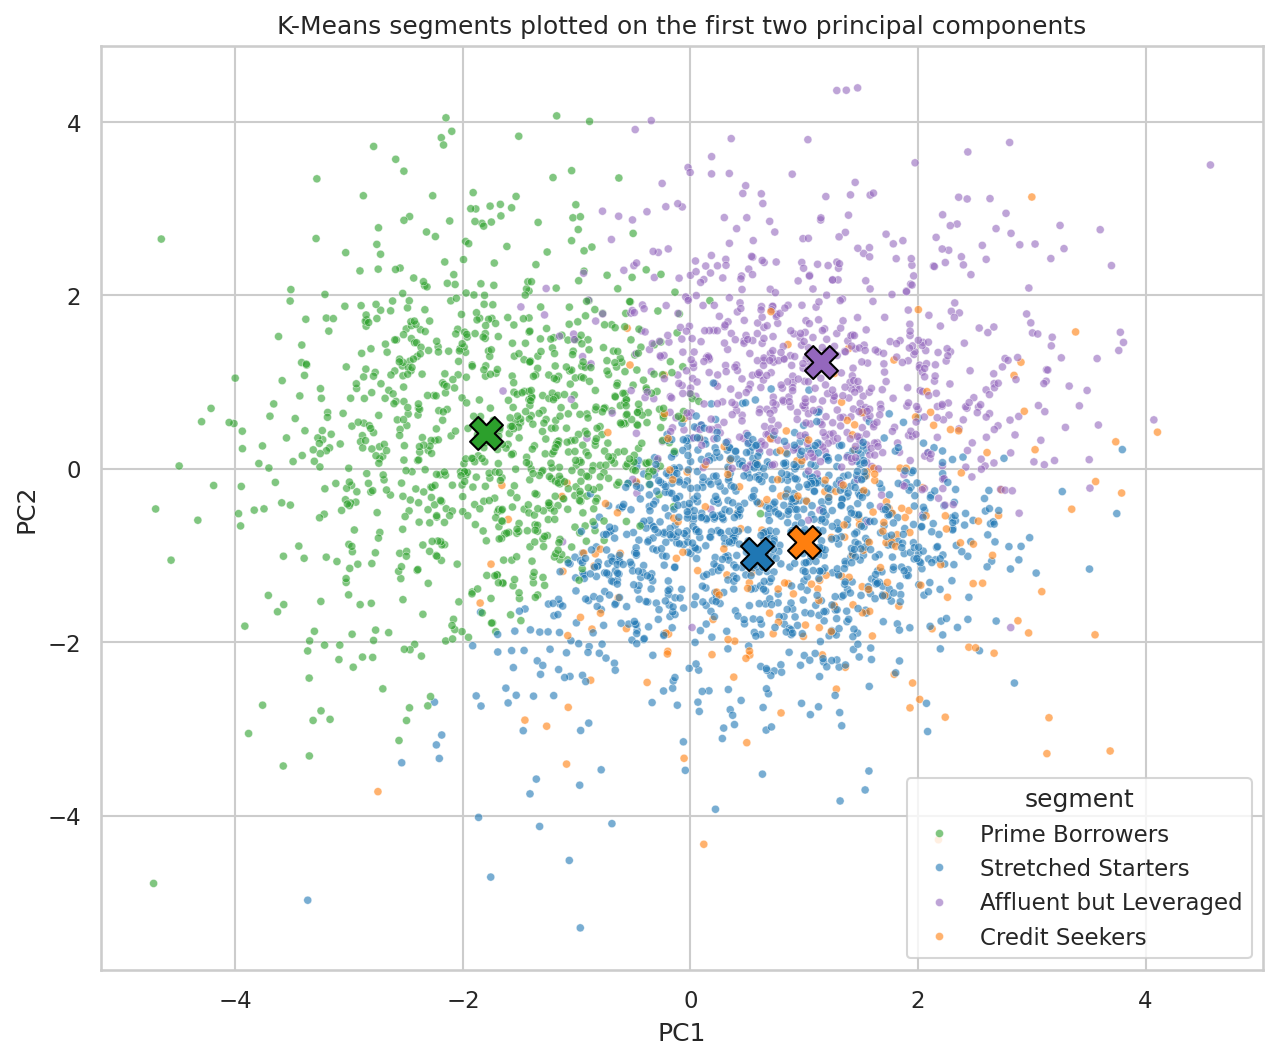

In [16]:
pts = df.iloc[idx]
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pts, x="PC1", y="PC2", hue="segment", hue_order=ORDER, palette=SEG_COLORS, alpha=0.6, s=15)
for seg in ORDER:
    m = df[df["segment"] == seg][["PC1", "PC2"]].mean()
    plt.scatter(m.PC1, m.PC2, marker="X", s=250, color=SEG_COLORS[seg], edgecolor="black")
plt.title("K-Means segments plotted on the first two principal components")
save_fig("fig_clusters_pca"); plt.show()
print(df.groupby("segment")[["PC1", "PC2"]].mean().loc[ORDER].round(2))

**Data-driven interpretation (extreme points in the biplot)** — see the table above
- **A (max PC1):** FICO 672, a 20% rate, 99% utilization and a \$952K revolving balance. Extreme leverage. A \$600K income also pushes it high on PC2.
- **B (min PC1):** FICO 797, a 7.4% rate, 0.5% utilization, DTI 0.4 and no revolving balance. The model low-risk borrower.
- **C (max PC2):** \$1.2M income, a 32-year credit history and FICO 807. Maximum capacity and maturity.
- **D (min PC2):** \$2K reported income, an 8-month credit history, a \$16 installment and 6 recent inquiries. **This loan defaulted.**
- The extremes also work as a data-quality check: incomes of \$2K and \$1.2M are worth verifying before modeling.

Default climbs steadily across PC1 quintiles (8% → 23%) even though PCA never saw the target. The risk axis the data finds on its own lines up with actual defaults. ROIC stays roughly flat across the same quintiles (19–25%): higher rates on riskier loans offset the extra defaults. PC2 has a milder default gradient (21% → 14%).

**How PCA guides modeling**
- The variance is **spread out**: 4 PCs explain only 62%, and 7 of 11 are needed for 80%. The variables are not redundant, so the Update 2 model should keep the original variables (they are also easier to explain to the ExCo) rather than compress to 2–3 components.
- PC1 bundles FICO, rate and utilization. Those are the collinear variables (r up to −0.71) to handle carefully in logistic regression: pick one or two, or check VIFs.
- Credit Seekers overlap other segments on PC1/PC2 because they differ on **PC3 (recent credit stress)**. Inquiries carry risk information the first two components miss, which is another reason to keep inquiries as a separate model input.

In [17]:
metrics = {
  "portfolio": portfolio,
  "tables": {k: t.reset_index().astype({t.index.name: str}).to_dict("records") for k, t in tables.items()},
  "rate_ranges": df.groupby("rate_quintile", observed=True)["int_rate"].agg(["min", "max"]).reset_index().astype({"rate_quintile": str}).to_dict("records"),
  "simpson": {str(k): v for k, v in df.pivot_table(index="fico_band", columns="credit_policy", values="default", observed=True).round(4).to_dict("index").items()},
  "policy_means": df.groupby("credit_policy")[["fico", "int_rate", "inq_last_6mths"]].mean().round(3).to_dict("index"),
  "corr_target": C["default"].drop("default").round(3).to_dict(),
  "corr_pairs": {"fico_rate": round(float(C.loc["fico", "int_rate"]), 3), "bal_util": round(float(C.loc["revol_bal", "revol_util"]), 3),
                 "fico_util": round(float(C.loc["fico", "revol_util"]), 3), "rate_util": round(float(C.loc["int_rate", "revol_util"]), 3),
                 "inq_policy": round(float(C.loc["inq_last_6mths", "credit_policy"]), 3)},
  "scree": scree.to_dict("records"), "kaiser": int((eig > 1).sum()),
  "n_pc_80": int(np.argmax(evr.cumsum() >= .8) + 1), "n_pc_90": int(np.argmax(evr.cumsum() >= .9) + 1),
  "loadings": loadings.round(3).to_dict("index"), "pc_names": PC_NAMES,
  "extremes": extremes.round(3).to_dict("index"),
  "by_pc1": by_pc1.reset_index().astype({"PC1_quintile": str}).to_dict("records"),
  "by_pc2": by_pc2.reset_index().astype({"PC2_quintile": str}).to_dict("records"),
  "k_diag": k_diag.fillna(0).to_dict("records"), "ari": [round(a, 3) for a in ari],
  "centers": centers.round(3).to_dict("index"), "profile": profile.round(4).to_dict("index"), "seg_kpi": seg_kpi.round(4).to_dict("index"),
  "purpose_mix": purpose_mix.round(3).to_dict("index"), "prototypes": prototypes.round(4).to_dict("index"),
  "drop_seekers": {"share_kept": round(float((df["segment"] != "Credit Seekers").mean()), 4),
                   "roic": round(float(df.loc[df["segment"] != "Credit Seekers", "profit"].sum() / df.loc[df["segment"] != "Credit Seekers", "principal"].sum()), 4),
                   "net_profit_m": round(float(df.loc[df["segment"] != "Credit Seekers", "profit"].sum()/1e6), 2),
                   "default_rate": round(float(df.loc[df["segment"] != "Credit Seekers", "default"].mean()), 4)},
}
with open("metrics.json", "w") as f: json.dump(metrics, f, indent=1, default=float)
print("Saved metrics.json and figures")

Saved metrics.json and figures


## 5. Summary for the ExCo and next steps
1. **Baseline:** 16.0% of \$75.3M in principal defaulted. Interest on paid loans (\$28.4M) minus principal lost (\$12.6M) gives **\$15.8M net, a 21.0% three-year ROIC**.
2. **Risk signals:** inquiries, FICO, purpose and the credit-policy flag separate both default and profit. Interest rate predicts default but pricing compensates everywhere except the riskiest pockets.
3. **Segments (K-Means, k = 4):** Prime Borrowers (8.5% default), Stretched Starters and Affluent but Leveraged (~18% default, most profitable), and **Credit Seekers (32% default, 0.7% ROIC)**.
4. **PCA:** the top component is a credit risk & leverage axis (default 8% → 23% across its quintiles). Variance is spread across components, so we keep the original variables for modeling.

**Next (Update 2):** logistic regression and decision trees on application-time fields only (no tot_payment, principal or interest). Handle the FICO–rate collinearity and the 16/84 class imbalance, and test whether the model beats the simple "exclude Credit Seekers" screen.